# Lab 2: Stata Basics

**课程**：经济与商务实证研究方法（RMEB） 2026 Spring  
**主题**：Stata 入门与 VS Code 一体化工作流  
**定位**：Week 2 计算环境搭建的配套实验

## 学习目标

完成本 notebook 后，你应该能够：

1. 在 VS Code 中直接运行 Stata notebook。
2. 理解 Stata 的基础数据生成与查看方式。
3. 跑一个最简单的回归并画一个基础图。
4. 理解为什么 Stata 不必再被局限在它自己的 GUI 里。

## 为什么要把 Stata 放进 Jupyter/VS Code？

Stata 的估计命令很强，但传统 GUI 工作流经常让代码、结果、笔记和 AI 工具彼此割裂。

这门课希望学生逐步适应一种新的方式：

- 在 **VS Code** 中统一写 Stata、Python、R、Julia。
- 用 **Copilot** 辅助补全命令和注释。
- 用 **Claude Code** 帮你解释回归输出、整理分析步骤和查错。
- Stata 的 `do file` 局限性很大，不利于可重复研究和与其他工具的整合。

**目标不是抛弃 Stata，而是让 Stata 融入更高效的可重复研究工作流。**

## 环境要求

运行本 notebook 前，请确保：

- VS Code 已安装 Jupyter 扩展。
- 当前 notebook 连接到 `Stata` kernel。
- 本机已安装并授权 Stata，且 kernel 已指向 StataMP 可执行文件。

如果图形没有正常显示，通常不是命令本身错误，而是 kernel 的图形显示链路需要重跑或刷新。

## 历史资料入口

如果你想快速回看往年 Stata 教材，可以按下面这条学习路线往前延伸：

### 入门：先熟悉 Stata notebook 工作流

- [Stata_Jupyter.ipynb](https://gitee.com/zhiyuanryanchen/econ-research-methods/blob/master/2020Fall/Lecture1/3-StataJupyter/Stata_Jupyter.ipynb): Stata kernel 在 Jupyter 中的基本用法，最适合先回顾 notebook 工作流。
- [Stata_Example_Jupyter.ipynb](https://gitee.com/zhiyuanryanchen/econ-research-methods/blob/master/2020Fall/Lecture1/2-DataVisualization/Stata_Example_Jupyter.ipynb): 一个更直观的 Stata notebook 示例，便于快速熟悉命令与输出展示。

### 中级：开始写更规范的经验分析流程

- [Results_e-class_r-class.ipynb](https://gitee.com/zhiyuanryanchen/econ-research-methods/blob/master/2020Fall/Lecture3/5-UsingStataResults/Results_e-class_r-class.ipynb): 理解 `r()` 和 `e()` 返回结果，适合开始写更规范的分析流程时查看。
- [PanelModels.ipynb](https://gitee.com/zhiyuanryanchen/econ-research-methods/blob/master/2020Fall/Lecture3/4-PanelModels/PanelModels.ipynb): 面板数据、固定效应和 `xtreg` 的历史讲义，适合学完基础后继续延伸。
- [DiffinDiff.ipynb](https://gitee.com/zhiyuanryanchen/econ-research-methods/blob/master/2020Fall/Lecture3/4-PanelModels/DiffinDiff.ipynb): 如果你想把 Stata 用到政策评估和 DID，这份材料可以继续看。
- [BootstrapMethods.ipynb](https://gitee.com/zhiyuanryanchen/econ-research-methods/blob/master/2020Fall/Lecture3/7-BootstrapMethods/BootstrapMethods.ipynb): 适合复习 bootstrap 在 Stata 里的基本实现方式。

### 高级：把 Stata 变成可扩展工具

- [AdvancedProgramming.ipynb](https://gitee.com/zhiyuanryanchen/econ-research-methods/blob/master/2020Fall/Lecture3/6-AdvancedProgramming/AdvancedProgramming.ipynb): 如果你希望自己写程序、封装命令、理解 ado-files 与 Mata，这里是最合适的下一站。

建议先完成本 lab，再按照“入门 → 中级 → 高级”的顺序选择性回看，不必一次全部读完。

In [2]:
clear all
set more off
display "Stata version: " c(stata_version)
display "Machine type: " c(machine_type)




Stata version: 18

Machine type: Mac (Apple Silicon)


## 1. 创建一个小数据集

In [3]:
clear
input id year treatment outcome
1 2024 0 10.2
1 2025 1 11.5
2 2024 0 9.8
2 2025 0 10.0
3 2024 1 12.1
3 2025 1 12.7
end

list
summarize outcome




            id       year  treatment    outcome


     +--------------------------------+
     | id   year   treatm~t   outcome |
     |--------------------------------|
  1. |  1   2024          0      10.2 |
  2. |  1   2025          1      11.5 |
  3. |  2   2024          0       9.8 |
  4. |  2   2025          0        10 |
  5. |  3   2024          1      12.1 |
     |--------------------------------|
  6. |  3   2025          1      12.7 |
     +--------------------------------+


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
     outcome |          6       11.05    1.217785        9.8       12.7


## 2. 生成新变量并回归

In [4]:
summarize outcome, meanonly
generate outcome_gap = outcome - r(mean)
reg outcome treatment, robust





Linear regression                               Number of obs     =          6
                                                F(1, 4)           =      33.08
                                                Prob > F          =     0.0045
                                                R-squared         =     0.8921
                                                Root MSE          =     .44721

------------------------------------------------------------------------------
             |               Robust
     outcome | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
   treatment |        2.1   .3651483     5.75   0.005     1.086186    3.113814
       _cons |         10   .1154699    86.60   0.000     9.679404     10.3206
------------------------------------------------------------------------------


## 3. 画一个简单图形

如果当前 kernel 配置正常，这个图会直接显示在 notebook 中。若没有看到图，通常需要重新运行该单元，或检查 Stata kernel 的图形导出设置。

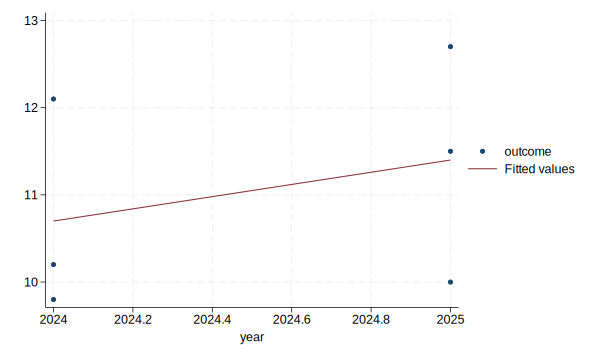


    format


In [5]:
twoway scatter outcome year, mcolor(navy) || lfit outcome year, lcolor(maroon)

## 4. 循环与控制流

Stata 提供 `forvalues`（数值循环）、`foreach`（列表循环）和 `while` 三种循环结构。

In [ ]:
* --- forvalues: 数值循环 ---
* 打印 1 到 5
forvalues i = 1/5 {
    display "当前 i = `i'"
}

* 步长循环: 2, 4, 6, 8, 10
forvalues j = 2(2)10 {
    display "偶数: `j'"
}

* --- foreach: 列表循环 ---
* 遍历变量名列表
sysuse auto, clear
foreach var of varlist price mpg weight {
    summarize `var', meanonly
    display "`var' 的均值 = " r(mean)
}

* 遍历字符串列表
foreach fruit in "苹果" "香蕉" "橙子" {
    display "我喜欢吃 `fruit'"
}

* --- while 循环 ---
local n = 1
local total = 0
while `n' <= 10 {
    local total = `total' + `n'
    local n = `n' + 1
}
display "1到10的和 = `total'"

* --- if/else 条件 ---
local score = 85
if `score' >= 90 {
    display "优秀"
}
else if `score' >= 80 {
    display "良好"
}
else {
    display "需努力"
}

## 5. 函数的写法 (program define)

Stata 使用 `program define` 创建自定义命令，用 `syntax` 解析参数。

In [ ]:
* --- 基本 program ---
capture program drop hello
program define hello
    display "你好，Stata 用户！"
end
hello

* --- 带参数的 program ---
capture program drop greet
program define greet
    args name
    display "你好，`name'！欢迎学习 Stata。"
end
greet "同学"

* --- 使用 syntax 解析参数（更规范）---
capture program drop desc_var
program define desc_var
    syntax varlist [if] [in]
    foreach var of varlist `varlist' {
        quietly summarize `var' `if' `in'
        display "`var': N=" r(N) " 均值=" %9.3f r(mean) " 标准差=" %9.3f r(sd)
    }
end

sysuse auto, clear
desc_var price mpg weight

* --- 返回值：r-class program ---
capture program drop my_sum
program define my_sum, rclass
    syntax varname
    quietly summarize `varlist'
    return scalar mean = r(mean)
    return scalar sd = r(sd)
    return scalar n = r(N)
end

my_sum price
display "均值 = " r(mean)
display "标准差 = " r(sd)

## 6. 高级用法入门

### 6.1 Local 与 Global 宏

Stata 的宏（macro）是其核心编程机制，理解 `local` 和 `global` 的区别至关重要。

### 6.2 Mata 基础

Mata 是 Stata 的矩阵编程语言，适合大规模矩阵计算。

### 6.3 Stata-Python 交互

Stata 16+ 支持直接在 do-file 中嵌入 Python 代码。

In [ ]:
* ===== 6.1 Local 与 Global 宏 =====
* local: 仅在当前 do-file/program 中可见
local greeting "你好，世界"
display "`greeting'"

* global: 全局可见（慎用，避免命名冲突）
global project_name "RMEB_2026"
display "$project_name"

* 宏在循环中的威力
local vars "price mpg weight length"
local n_vars : word count `vars'
display "变量数量: `n_vars'"

forvalues i = 1/`n_vars' {
    local v : word `i' of `vars'
    display "第`i'个变量: `v'"
}

* 存储回归结果
sysuse auto, clear
reg price mpg weight
local r2 : display %5.3f e(r2)
local nobs = e(N)
display "R² = `r2', N = `nobs'"

* ===== 6.2 Mata 基础 =====
mata:
    // 创建矩阵
    A = (1, 2, 3 \ 4, 5, 6 \ 7, 8, 9)
    A
    
    // 矩阵运算
    B = A' * A     // 转置相乘
    B
    
    // 求逆（伪逆）
    C = (1, 2 \ 3, 4)
    D = luinv(C)
    D
    
    // OLS: beta = (X'X)^(-1) X'y
    // 从 Stata 数据读入
    st_view(y=., ., "price")
    st_view(X=., ., ("mpg", "weight"))
    X = X, J(rows(X), 1, 1)  // 加常数项
    
    beta = luinv(X'X) * X'y
    "OLS 系数 (mpg, weight, _cons):"
    beta'
end

* ===== 6.3 Stata-Python 交互 =====
python:
import numpy as np
from sfi import Data, Macro

# 从 Stata 读取数据
price = np.array(Data.get(var='price'))
mpg = np.array(Data.get(var='mpg'))

# Python 计算
corr = np.corrcoef(price, mpg)[0, 1]
print(f"价格与油耗的相关系数: {corr:.4f}")

# 将结果传回 Stata
Macro.setLocal('py_corr', f'{corr:.4f}')
end

display "Python 计算的相关系数: `py_corr'"

## ✨ Stata 杀手锏预览：三行代码完成面板回归表

Stata 在面板数据计量经济学中的地位无可替代。回归、存储、列表——三步完成一篇论文核心结果表的雏形。语法之简洁，让你把精力集中在研究设计而非编程细节上。

> 💡 **研究中的组合优势**：Stata 的回归命令极其简洁 + R/Python 的可视化灵活强大 + Julia 的大规模模拟速度无敌——各取所长。

In [2]:
* Stata 的杀手锏：三行代码完成一篇论文的核心回归表
sysuse auto, clear

* 模型1：基准回归
quietly reg price mpg weight, robust
estimates store m1

* 模型2：加入控制变量
quietly reg price mpg weight length, robust
estimates store m2

* 模型3：加入分类变量
quietly reg price mpg weight length i.foreign, robust
estimates store m3

* 一行命令：对比三个模型，星号标注显著性
estimates table m1 m2 m3, star(.1 .05 .01) stats(N r2)


(1978 automobile data)








--------------------------------------------------------------
    Variable |      m1              m2              m3        
-------------+------------------------------------------------
         mpg | -49.512221      -86.789284      -13.407192     
      weight |  1.7465592**     4.3647979**     5.7161809***  
      length |                 -104.86817*     -92.480183*    
             |
     foreign |
    Foreign  |                                  3550.1937***  
             |
       _cons |  1946.0687       14542.434**     5515.5801     
-------------+------------------------------------------------
           N |         74              74              74     
          r2 |  .29338912       .35737644       .54909139     
--------------------------------------------------------------
                           Legend: * p<.1; ** p<.05; *** p<.01


## 4. 练习

1. 新建变量 `treated_outcome = treatment * outcome`。
2. 只保留 2025 年样本并重新做一次 `summarize`。
3. 让 Copilot 帮你把 `reg outcome treatment, robust` 改写成加入年份虚拟变量的形式。

In [ ]:
* TODO: 在这里写你的练习代码